<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Query Linked Catalogue Tables in the VVVX Survey**

This notebook demonstrates a science case for the `VVVX` / `VIRAC2` catalogue family, where source, light-curve, and observation metadata are spread across multiple linked tables.

The workflow shows how to:

- discover the available `VVVX` catalogue tables through the catalogue TAP metadata
- query a manageable subset of the main source table and visualise the sky distribution
- run more selective ADQL science queries against the source table
- join the source and light-curve tables to recover the `Ks`-band light curve of `VVV-WIT-08`
- repeat the same pattern for a small set of highly sampled sources

--- 

**Authors**: Emanuele Paolo Farina & Ashley Thomas Barnes

<hr style="border:2px solid #0281c9"> </hr>

# **Importing and basic usage of astroquery.eso**

In [1]:
import astroquery # import astroquery
print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

astroquery version: 0.4.12.dev505+gf2a77a615.d20260427


In [2]:
from astroquery.eso import Eso # import the ESO module from astroquery

from astropy.coordinates import SkyCoord # sky coordinates
from astropy.time import Time # date conversions
import astropy.units as u # units
import matplotlib.pyplot as plt # plotting
import numpy as np # numerical tools
from pathlib import Path # filesystem paths

In [3]:
eso = Eso() # create an instance of the ESO class

# **Discover the VVVX catalogue tables**

The first step is to inspect the catalogue metadata and identify the `VVVX` tables we want to work with.

In [4]:
query = """
        SELECT collection, table_name, title, version, publication_date
        FROM TAP_SCHEMA.tables
        WHERE collection = 'VVVX'
        ORDER BY table_name
        """

vvvx_tables = eso.query_tap(query, tap_endpoint="tap_cat")
vvvx_tables

collection,table_name,title,version,publication_date
object,object,object,int32,object
VVVX,VVVX_VIRAC_V2_LC,VIRAC2 time series,1,2024-12-18T08:23:10Z
VVVX,VVVX_VIRAC_V2_OBS,VIRAC2 observation details,1,2024-12-17T12:57:06Z
VVVX,VVVX_VIRAC_V2_REJECTED_LC,VIRAC2 time series - Rejected Sources,1,2024-12-18T08:23:11Z
VVVX,VVVX_VIRAC_V2_REJECTED_SOURCES,VIRAC2 source catalogue - Rejected Sources,1,2024-12-17T12:57:06Z
VVVX,VVVX_VIRAC_V2_SOURCES,VIRAC2 source catalogue,1,2024-12-17T11:08:10Z


In [5]:
tablename_vvvx_sources = 'VVVX_VIRAC_V2_SOURCES'
tablename_vvvx_sources_rejected = 'VVVX_VIRAC_V2_REJECTED_SOURCES'
tablename_vvvx_sources_lc = 'VVVX_VIRAC_V2_LC'
tablename_vvvx_sources_lc_rejected = 'VVVX_VIRAC_V2_REJECTED_LC'
tablename_vvvx_obs = 'VVVX_VIRAC_V2_OBS'

Check some of the metadata fields for the columns.

In [19]:
query = f"""
        SELECT column_name, datatype, unit, ucd
        FROM TAP_SCHEMA.columns
        WHERE table_name = '{tablename_vvvx_sources}'
        ORDER BY column_name
        """

vvvx_source_columns = eso.query_tap(query, tap_endpoint="tap_cat")
vvvx_source_columns[:5]

column_name,datatype,unit,ucd
object,object,object,object
astfit_epochs,SMALLINT,,meta.number;time.epoch
astfit_params,SMALLINT,,meta.number
chisq,REAL,,stat.fit.chi2
de,DOUBLE,deg,pos.eq.dec;meta.main
de_error,DOUBLE,mas,stat.error;pos.eq.dec


More specifically, if we want to know which columns contain e.g. the source positions, we can check the `ucd` field for the value `pos.eq.ra` and `pos.eq.dec` for the right ascension and declination, respectively. We can do this using the below helper function, which queries the TAP metadata and returns a list of column names matching the specified `ucd` value.

In [7]:
MAIN_UCD_TO_KEY = {
    "meta.id;meta.main": "id",
    "pos.eq.ra;meta.main": "ra",
    "pos.eq.dec;meta.main": "dec",
}

def get_main_catalog_columns(catalog_name):
    """Return the main id/ra/dec columns for one catalogue table."""
    query = f"""
        SELECT column_name, ucd
        FROM TAP_SCHEMA.columns
        WHERE table_name = '{catalog_name}'
          AND ucd IN ('meta.id;meta.main', 'pos.eq.ra;meta.main', 'pos.eq.dec;meta.main')
    """

    rows = eso.query_tap(query, tap_endpoint="tap_cat")
    main_cols = {"id": None, "ra": None, "dec": None}

    for row in rows:
        key = MAIN_UCD_TO_KEY.get(row["ucd"])
        if key and main_cols[key] is None:
            main_cols[key] = row["column_name"]

    return main_cols

main_cols = get_main_catalog_columns(tablename_vvvx_sources)
main_cols

{'id': 'sourceid', 'ra': 'ra', 'dec': 'de'}

# **Query a manageable subset of the source table**

The full `VVVX_VIRAC_V2_SOURCES` table is very large, so for quick exploration it is useful to work with a limited subset. Here we retrieve the brightest sources in `Ks` by ordering directly in ADQL.

In [8]:
query = f"""
        SELECT TOP 1000000 sourceid, {main_cols['ra']}, {main_cols['dec']}
        FROM {tablename_vvvx_sources}
        ORDER BY phot_ks_mean_mag ASC
        """

eso.ROW_LIMIT = 1000000 # increase or set to None for larger comparisons
table_vvvx_sources = eso.query_tap(query, tap_endpoint="tap_cat")
print(f"Number of sources retrieved: {len(table_vvvx_sources)}")
table_vvvx_sources[:3]

Number of sources retrieved: 1000000


sourceid,ra,de
,deg,deg
int64,float64,float64
15935140001254,225.26871015779477,-59.96964722402098
15942908004877,225.2183426486327,-60.155179428828696
15945490000379,225.26412822146185,-60.17273233114854


With that subset in hand, we can make a quick-look sky-distribution plot.

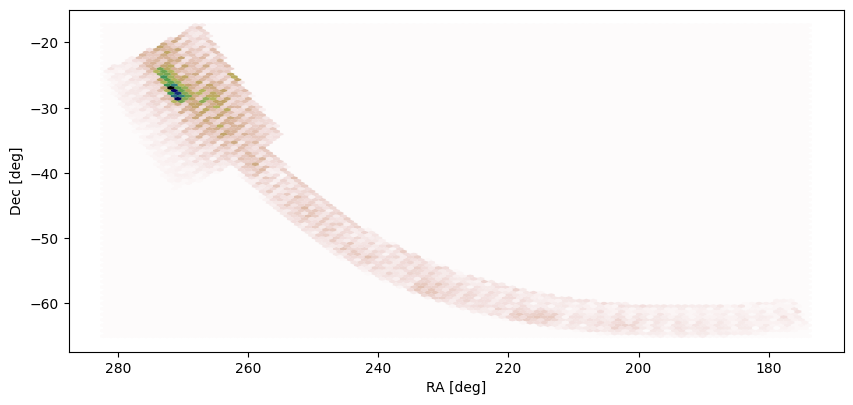

In [9]:
Path('figures').mkdir(exist_ok=True)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.set_aspect('equal')

ax.hexbin(table_vvvx_sources[main_cols['ra']], table_vvvx_sources[main_cols['dec']], 
          cmap='gist_earth_r', linewidths=0.1)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.invert_xaxis()

fig.savefig('./figures/VVVX_sources_sky_distribution.png', dpi=300, bbox_inches='tight')

# **Run more selective science queries with ADQL**

For large linked catalogues, free ADQL through `query_tap()` is often the most flexible approach. 

Below are two examples: one targeting high proper-motion candidates (section 4.1.1 of Smith et al. 2025) and one targeting nearby-star candidates (section 4.1.3 of Smith et al. 2025).

In [10]:
query = f"""
        SELECT *
        FROM {tablename_vvvx_sources}
        WHERE parallax > 10
        AND parallax / parallax_error >= 5
        AND ks_n_det > 0.5 * ks_n_obs
        AND sqrt(power(pmra, 2) + power(pmde, 2)) > 500
        AND ks_n_amb < 0.4 * ks_n_det
        AND ks_last_epoch - ks_first_epoch > 0.5 * 365.2422
        AND ks_n_det > 20
        """

high_pm_candidates = eso.query_tap(query, tap_endpoint="tap_cat")
high_pm_candidates[:3]

astfit_epochs,astfit_params,chisq,de,de_error,de_parallax_corr,de_pmde_corr,de_pmra_corr,duplicate,h_n_amb,h_n_det,h_n_obs,j_n_amb,j_n_det,j_n_obs,ks_Stetson_I,ks_Stetson_J,ks_Stetson_K,ks_Stetson_group_count,ks_eta,ks_eta_f,ks_first_epoch,ks_last_epoch,ks_mad,ks_med_err,ks_n_amb,ks_n_det,ks_n_obs,ks_p0,ks_p1,ks_p100,ks_p16,ks_p2,ks_p25,ks_p32,ks_p4,ks_p5,ks_p50,ks_p68,ks_p75,ks_p8,ks_p84,ks_p92,ks_p95,ks_p96,ks_p98,ks_p99,ks_skew,parallax,parallax_error,parallax_pmde_corr,parallax_pmra_corr,phot_h_mean_mag,phot_h_n_epochs,phot_h_std_mag,phot_j_mean_mag,phot_j_n_epochs,phot_j_std_mag,phot_ks_mean_mag,phot_ks_n_epochs,phot_ks_std_mag,phot_y_mean_mag,phot_y_n_epochs,phot_y_std_mag,phot_z_mean_mag,phot_z_n_epochs,phot_z_std_mag,pmde,pmde_error,pmra,pmra_error,pmra_pmde_corr,ra,ra_de_corr,ra_error,ra_parallax_corr,ra_pmde_corr,ra_pmra_corr,ref_epoch,sourceid,uwe,y_n_amb,y_n_det,y_n_obs,z_n_amb,z_n_det,z_n_obs
,,,deg,mas,,,,,,,,,,,,,,,,,d,d,mag,mag,,,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,mas,mas,,,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mas / yr,mas / yr,mas / yr,mas / yr,,deg,,mas,,,,yr,,,,,,,,
int16,int16,float32,float64,float64,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,float64,float64,float64,int32,float64,float64,float64,float64,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,int64,float32,int16,int16,int16,int16,int16,int16
186,5,306.0574,-34.67343948470384,0.24487962952394715,0.018261325,0.101412594,-0.0074607697,0,8,12,12,9,13,13,0.14303103824678648,0.11827582327951655,0.7642475296627691,86,1.7698554908565982,1216824769.1811159,55444.01943446,58717.134680970004,0.008493423,0.01655115,12,186,188,12.744979,12.752619,12.888269,12.766132,12.756135,12.770881,12.773408,12.75856,12.759347,12.778631,12.785298,12.787492,12.76052,12.790328,12.792994,12.796844,12.798289,12.8012905,12.827868,2.7455304,16.701090631088064,0.7351169408375946,-0.0100412,-0.40855578,13.0613575,4,0.0059218328,13.529919,4,0.009546029,12.779375,174,0.015512448,14.034725,2,0.0008263589,14.548061,2,0.00028562587,-496.61012216757626,0.3062773985291653,125.26121467522779,0.37135424097064046,0.0041023903,257.6270270669558,0.0054955217,0.17353025391522597,0.3009377,-0.003021776,0.33462676,2014.0,14066547002206,0.91320527,2,4,4,2,4,4
162,5,242.18576,-38.533389943971265,0.1769205750920328,0.14911465,0.3565461,0.038030617,0,0,4,5,0,4,5,0.087311052600148,0.10740581134723766,0.7616244500160707,80,1.9381286779866513,1205647235.5077407,55305.34079404,58704.17423642,0.0073657036,0.013670492,0,162,163,12.002927,12.011094,12.172001,12.062519,12.042366,12.066527,12.068782,12.045084,12.046876,12.074949,12.079354,12.080839,12.056369,12.083654,12.095353,12.099904,12.104187,12.111498,12.127402,0.45265073,28.125388800687134,0.7341532773884217,0.0016077232,0.2550428,12.357675,4,0.009727461,12.8070965,4,0.0036149966,12.074201,162,0.018217996,13.325228,4,0.005519425,13.972042,4,0.003741709,-631.353902347714,0.3494449548807822,-63.70521220698487,0.3110955577551357,0.0004100382,272.58880302275264,-0.04998967,0.9199975837572675,-0.33524317,-0.00053897826,-0.11605423,2014.0,14402589000670,0.8713226,0,4,4,0,4,4
163,5,259.3633,-29.857004297143117,0.9675819411589733,-0.0002672085,-0.0020440505,1.2215755e-05,0,0,3,4,0,4,4,0.6029438662227287,0.4026595314125138,0.7317790627933308,80,1.8075404965827642,1578548283.6348386,55327.35271073,58721.15277608,0.012581825,0.01617827,0,163,167,11.354024,11.357756,11.803862,11.373629,11.359555,11.378078,11.381519,11.361892,11.362294,11.388228,11.397986,11.40229,11.366852,11.410763,11.436421,11.455499,11.460777,11.

In [11]:
query = f"""
        SELECT *
        FROM {tablename_vvvx_sources}
        WHERE parallax > 20
        AND parallax / parallax_error >= 5
        AND ks_n_det > 0.5 * ks_n_obs
        AND ks_n_amb < 0.4 * ks_n_det
        AND ks_last_epoch - ks_first_epoch > 6 * 365.2422
        AND ks_n_det > 20
        AND sqrt(power(pmra, 2) + power(pmde, 2)) > 30
        AND uwe < 1.2
        AND 4.74 * sqrt(power(pmra, 2) + power(pmde, 2)) / parallax > 5
        """

nearby_candidates = eso.query_tap(query, tap_endpoint="tap_cat")
nearby_candidates[:3]

astfit_epochs,astfit_params,chisq,de,de_error,de_parallax_corr,de_pmde_corr,de_pmra_corr,duplicate,h_n_amb,h_n_det,h_n_obs,j_n_amb,j_n_det,j_n_obs,ks_Stetson_I,ks_Stetson_J,ks_Stetson_K,ks_Stetson_group_count,ks_eta,ks_eta_f,ks_first_epoch,ks_last_epoch,ks_mad,ks_med_err,ks_n_amb,ks_n_det,ks_n_obs,ks_p0,ks_p1,ks_p100,ks_p16,ks_p2,ks_p25,ks_p32,ks_p4,ks_p5,ks_p50,ks_p68,ks_p75,ks_p8,ks_p84,ks_p92,ks_p95,ks_p96,ks_p98,ks_p99,ks_skew,parallax,parallax_error,parallax_pmde_corr,parallax_pmra_corr,phot_h_mean_mag,phot_h_n_epochs,phot_h_std_mag,phot_j_mean_mag,phot_j_n_epochs,phot_j_std_mag,phot_ks_mean_mag,phot_ks_n_epochs,phot_ks_std_mag,phot_y_mean_mag,phot_y_n_epochs,phot_y_std_mag,phot_z_mean_mag,phot_z_n_epochs,phot_z_std_mag,pmde,pmde_error,pmra,pmra_error,pmra_pmde_corr,ra,ra_de_corr,ra_error,ra_parallax_corr,ra_pmde_corr,ra_pmra_corr,ref_epoch,sourceid,uwe,y_n_amb,y_n_det,y_n_obs,z_n_amb,z_n_det,z_n_obs
,,,deg,mas,,,,,,,,,,,,,,,,,d,d,mag,mag,,,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,mas,mas,,,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mas / yr,mas / yr,mas / yr,mas / yr,,deg,,mas,,,,yr,,,,,,,,
int16,int16,float32,float64,float64,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,float64,float64,float64,int32,float64,float64,float64,float64,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float32,int16,float32,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,int64,float32,int16,int16,int16,int16,int16,int16
140,5,328.84283,-28.8923674647117,10.477483405740077,0.07158265,0.5911423,0.02424299,0,0,0,22,0,0,35,0.006161698360249133,-0.12453199410645553,0.8055775311387341,52,1.82143897240745,495914651.967841,55423.14572398,58363.02926792,0.1326065,0.26616895,0,140,240,15.293525,16.095482,17.193855,16.368372,16.153156,16.425444,16.451807,16.226412,16.23767,16.53833,16.655329,16.700932,16.293455,16.755966,16.84765,16.884342,16.901283,16.946531,16.978065,-1.0458663,67.66196426706044,12.85732906678998,-0.00033420263,0.3386713,--,0,--,--,0,--,16.55116,140,0.22255044,--,0,--,--,0,--,-71.83897229542193,6.320984238149826,-46.78787181954619,7.17417427981721,-0.00011318483,266.44809849847064,0.0076029855,11.129678076389576,0.106212676,-3.5496556e-05,0.59104735,2014.0,13525975009980,1.0935228,0,0,4,0,0,4
315,5,831.29254,-28.907133647421187,5.877013069713865,0.06218626,0.3641639,0.0061906492,0,0,2,44,0,0,71,0.11888773964844515,0.06595933925927788,0.7970079148526915,139,1.7619197922791634,1181557873.9035723,55423.14393939,58550.3540075,0.108055115,0.20587473,0,315,479,16.162285,16.183445,16.946934,16.340109,16.201454,16.38234,16.40407,16.227423,16.2342,16.48258,16.563898,16.595474,16.26791,16.658592,16.716146,16.761492,16.78976,16.834366,16.87146,0.26399276,78.21275517585775,7.651831317605119,-0.0041160057,0.09955011,18.119307,2,0.33703804,--,0,--,16.49201,315,0.15716074,--,0,--,--,0,--,-1.0975747114296932,3.3533044774178475,-111.24919432439577,3.6120791624739588,-0.00040974884,266.44902374107187,0.00894905,6.255188914634609,0.14390719,-0.00059232285,0.3875895,2014.0,13525975019196,1.1532857,0,0,8,0,0,8
625,5,1531.6473,-28.776502129854173,1.651772087420051,0.05615248,-0.3998847,0.0044387947,0,0,5,6,0,5,5,0.8807985163844132,0.599323200778032,0.7863249447329783,295,1.1548164149336102,320474418.3073732,55439.15739162,57841.39401207,0.05804491,0.08312824,2,626,666,13.659352,14.062189,15.391679,14.371161,14.105025,14.419374,14.4487705,14.189481,14.213596,14.496935,14.533848,14.5469265,14.289631,14.568995,14.601672,14.6154,14.62476,14.6510315,14.683677,-0.87685347,22.24629059419016,2.3978306883458482,0.006056101,0.079048954,14.742351,5,0.07758775,15.192987,5,0.122273795,14.471001,624,0.1315

# **Link the source and light-curve tables**

It can be that the source position and it properties are given in seperate tables. For example, here the source positions are stored in one table and the time-series measurements are stored in another. We can, nonetheless, easlity recover the source identifier from sky position, then use it to retrieve the linked light curve.

Here we retrieve the source `VVV-WIT-08`, using its sky position rather than assuming we already know the arbitrary ID in the catalogue (`sourceid`).

In [12]:
target_position = SkyCoord(
    ra=270.19756577655266,
    dec=-30.602574781446368,
    unit=(u.deg, u.deg),
    frame='icrs',
)
target_position = SkyCoord.from_name("VVV-WIT-08")

search_radius_deg = (1 * u.arcsec).to_value(u.deg)

query = f"""
        SELECT TOP 1 sourceid, {main_cols['ra']}, {main_cols['dec']}
        FROM {tablename_vvvx_sources}
        WHERE CONTAINS(
            POINT('ICRS', {main_cols['ra']}, {main_cols['dec']}),
            CIRCLE('ICRS', {target_position.ra.deg}, {target_position.dec.deg}, {search_radius_deg})
        ) = 1
        """

table_vvvx_source = eso.query_tap(query, tap_endpoint="tap_cat")
table_vvvx_source

sourceid,ra,de
,deg,deg
int64,float64,float64
13689858016587,270.19756577655266,-30.602574781446368


Now we know the `sourceid` for `VVV-WIT-08`, we can query the linked light-curve table to retrieve the time-series measurements.

In [13]:
sourceid = int(table_vvvx_source['sourceid'][0])

eso.ROW_LIMIT = 3000
table_vvvx_source_lc = eso.query_catalog(
                                catalog=tablename_vvvx_sources_lc,
                                columns=['mjdobs', 'filter', 'mag', 'emag'],
                                column_filters={'sourceid': f'= {sourceid}'},
                                )                   

table_vvvx_source_lc[:3]

mjdobs,filter,mag,emag
d,,mag,mag
float64,object,float32,float32
55308.34794789,H,11.858241,0.016689751
55308.35030773,Ks,11.5200405,0.018548632
55308.35330273,J,12.778993,0.010819146


## **PLotting the light curve**

Finally, we can make a quick-look plot of the `Ks`-band light curve.

**Helper function**: The below ``mjd_to_fractional_year`` function is used to convert the Modified Julian Date (MJD) time stamps of the light curve measurements into fractional years, which can be more intuitive for visualisation and interpretation.

In [14]:
def mjd_to_fractional_year(mjd_array):
    """Convert Modified Julian Dates to fractional years."""
    times = Time(mjd_array, format='mjd')
    years = times.datetime64.astype('datetime64[Y]').astype(int) + 1970
    year_start = Time([f'{year}-01-01T00:00:00' for year in years])
    next_year_start = Time([f'{year + 1}-01-01T00:00:00' for year in years])
    return years + (times.mjd - year_start.mjd) / (next_year_start.mjd - year_start.mjd)

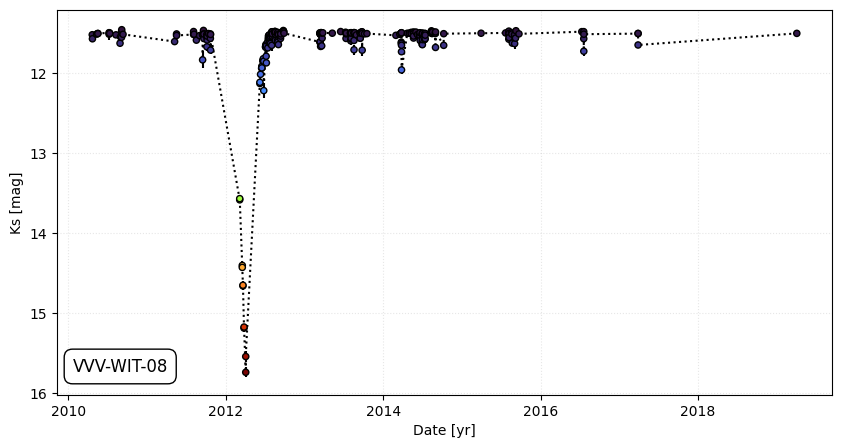

In [15]:
ks_mask = np.asarray(table_vvvx_source_lc['filter']) == 'Ks'

mjdobs = np.asarray(table_vvvx_source_lc['mjdobs'][ks_mask])
dateobs = mjd_to_fractional_year(mjdobs)
mag = np.asarray(table_vvvx_source_lc['mag'][ks_mask])
mag_err = np.asarray(table_vvvx_source_lc['emag'][ks_mask])

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)

ax.errorbar(dateobs, mag, yerr=mag_err, fmt='o', ms=0, ecolor='k', alpha=1)
ax.plot(dateobs, mag, color='k', ls=":")
ax.scatter(dateobs, mag, c=mag, cmap='turbo', ec='k', s=20, zorder=3)
ax.invert_yaxis()
ax.set_xlabel('Date [yr]')
ax.set_ylabel('Ks [mag]')
ax.grid(True, linestyle=':', alpha=0.3)
ax.text(0.02, 0.05, 'VVV-WIT-08', transform=ax.transAxes,
        fontsize=12, ha='left', va='bottom',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
        )

fig.savefig('./figures/VVV-WIT-08_lc.png', dpi=300, bbox_inches='tight')

## **Retrieve light curves for highly variable, well-sampled sources**

The linked-table approach used above can be extended to multiple targets. Here, we first select a subset of sources that are both well-sampled and strongly variable, and then retrieve their corresponding time-series data from the linked light-curve table.

The selection is based on a combination of the number of $K_s$-band detections (`ks_n_det`) and variability diagnostics derived from the light curves. In particular, we define a simple variability score as the product of the amplitude (estimated from the percentile range, `ks_p95 - ks_p5`) and the Stetson $J$ index (`ks_Stetson_J`), which captures correlated variability.

We then select the top sources ranked by this variability score, requiring a large number of detections (`ks_n_det > 1000`) to ensure well-sampled light curves. For each source, the catalogue entry is matched via its `sourceid` to the associated measurements in the light-curve table, allowing the full photometric time series to be reconstructed.

In [16]:
top = 25

query = f"""
        SELECT TOP {top}
            sourceid,
            ra,
            de,
            phot_ks_mean_mag,
            phot_z_mean_mag,
            phot_j_mean_mag,
            ks_n_det,
            ks_p95,
            ks_p5,
            ks_p95 - ks_p5 AS ks_amp,
            ks_Stetson_J,
            (ks_p95 - ks_p5) * ks_Stetson_J AS var_score
        FROM {tablename_vvvx_sources}
        WHERE ks_n_det > 1000
        AND ks_Stetson_J > 0
        AND ks_p95 IS NOT NULL
        AND ks_p5 IS NOT NULL
        AND ks_Stetson_J IS NOT NULL
        ORDER BY var_score DESC
        """     

top_sources = eso.query_tap(query, tap_endpoint="tap_cat")
top_sources[:3]

sourceid,ra,de,phot_ks_mean_mag,phot_z_mean_mag,phot_j_mean_mag,ks_n_det,ks_p95,ks_p5,ks_amp,ks_Stetson_J,var_score
,deg,deg,mag,mag,mag,,mag,mag,,,
int64,float64,float64,float32,float32,float32,int16,float32,float32,float64,float64,float64
13214733004189,271.19172577119923,-25.663933606073353,12.612402,18.102636,16.817886,1239,14.089341,11.48061,2.608731269836426,32.650958319282786,85.1775759576388
13394943008901,269.9625848048843,-27.54841407873312,14.5407715,--,--,1197,16.380093,11.7964735,4.583619117736816,14.471331986675773,66.33107395324338
13374477002047,271.16715559145774,-27.318316938166276,15.182853,--,--,1014,16.417488,12.964325,3.4531631469726562,11.684575197795828,40.34874446105929


From the above, we again now now source IDs that we can loop through and query the linked light-curve table for each one, storing the results in a list.

In [17]:
eso.ROW_LIMIT = 3000

top_source_lightcurves = []
for sourceid in top_sources['sourceid']:
    lc = eso.query_catalog(
        catalog=tablename_vvvx_sources_lc,
        columns=['sourceid', 'mjdobs', 'filter', 'mag', 'emag'],
        column_filters={'sourceid': f'= {int(sourceid)}'},
    )
    top_source_lightcurves.append(lc)

Plot results in a multi-panel figure.

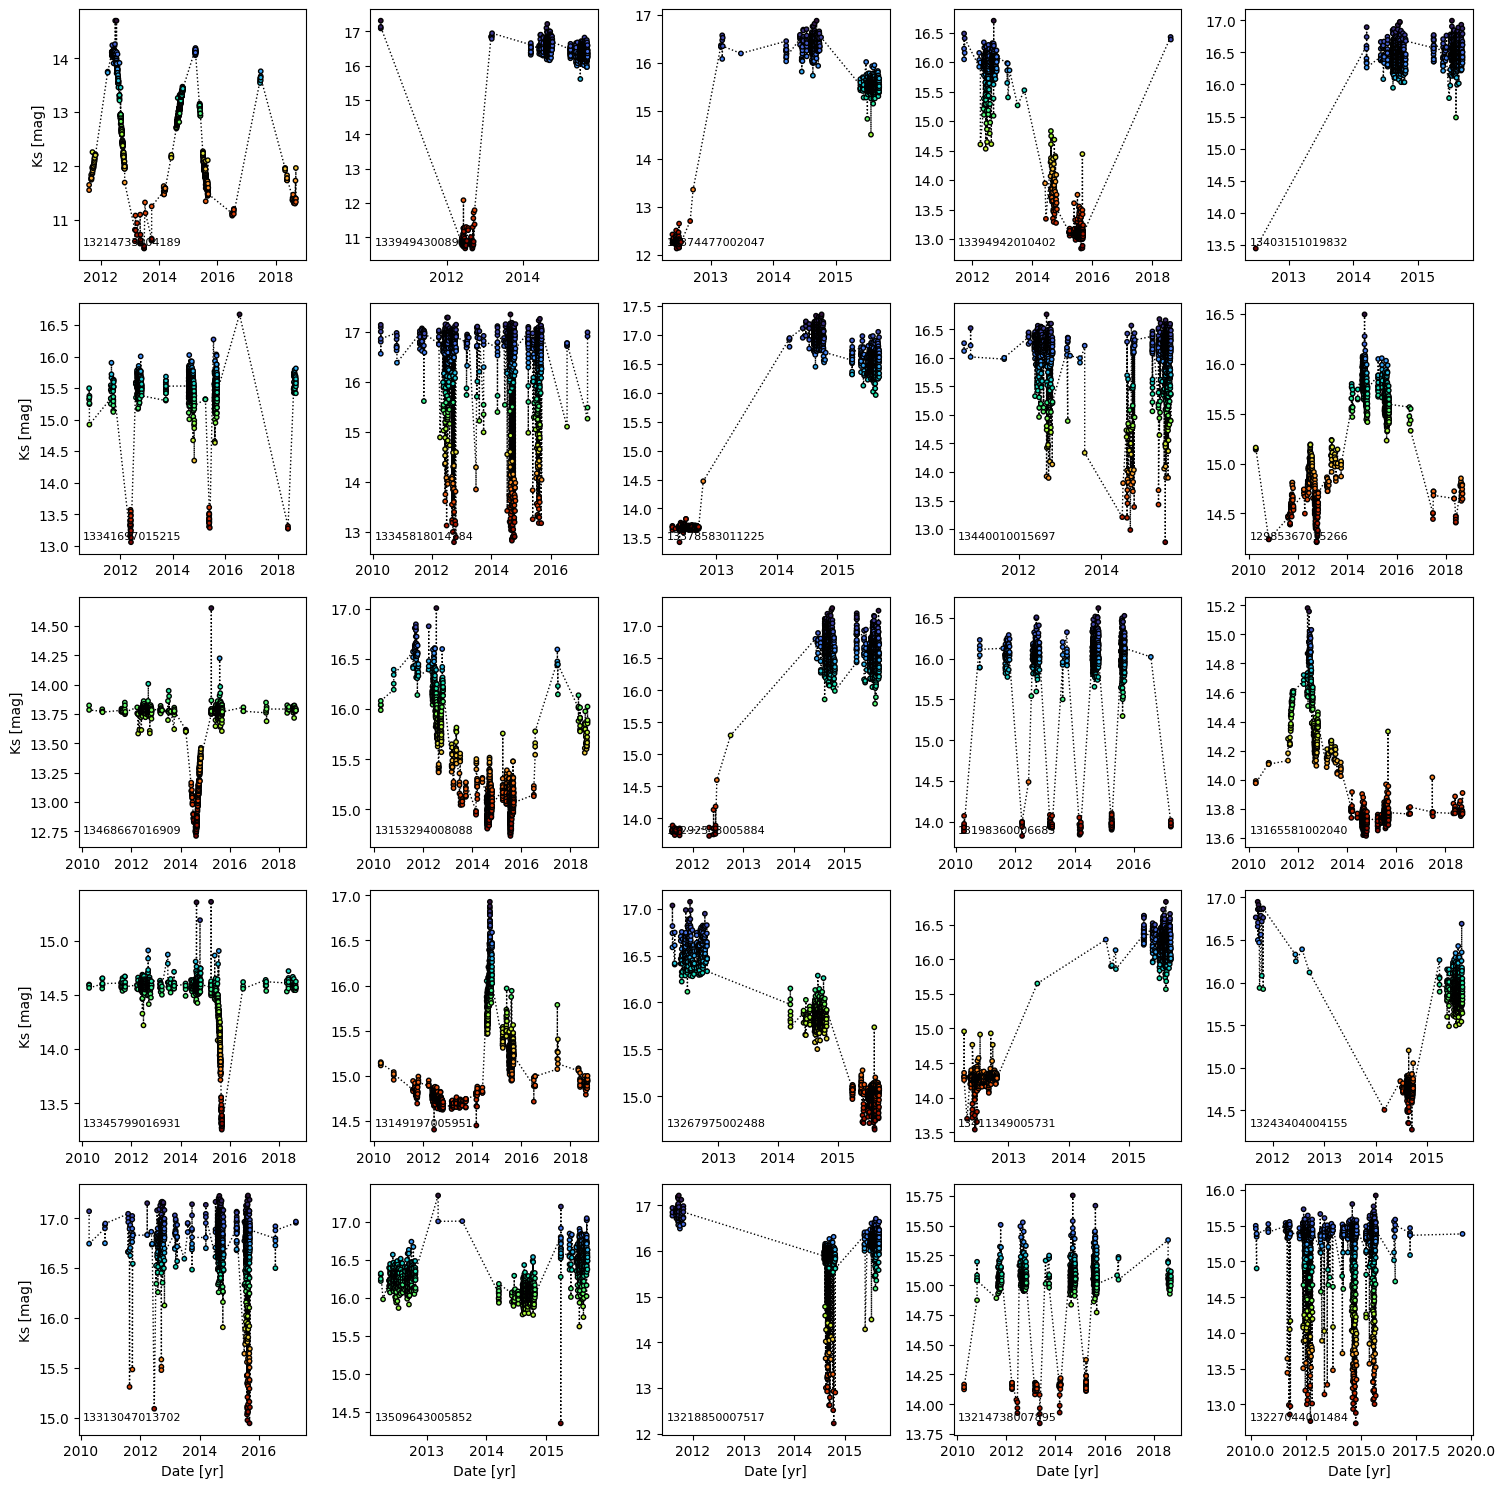

In [18]:
def label_axes(ax, i, num_rows, num_cols):
    """Label axes for a grid of small-multiple light curves."""
    row = i // num_cols
    col = i % num_cols

    if col == 0:
        ax.set_ylabel('Ks [mag]')
    # else:
    #     ax.set_yticklabels([])

    if row == num_rows - 1:
        ax.set_xlabel('Date [yr]')
    # else:
    #     ax.set_xticklabels([])

fig = plt.figure(figsize=(15, 15))
num_rows, num_cols = 5, 5

for i, table_vvvx_source_lc in enumerate(top_source_lightcurves):
    ks_mask = np.asarray(table_vvvx_source_lc['filter']) == 'Ks'
    if not np.any(ks_mask):
        continue

    mjdobs = np.asarray(table_vvvx_source_lc['mjdobs'][ks_mask])
    dateobs = mjd_to_fractional_year(mjdobs)
    mag = np.asarray(table_vvvx_source_lc['mag'][ks_mask])

    ax = fig.add_subplot(num_rows, num_cols, i + 1)
    ax.plot(dateobs, mag, alpha=1, color='k', ls=":", lw=1)
    ax.scatter(dateobs, mag, c=mag, cmap='turbo_r', s=10, ec='k', zorder=3)
    ax.text(0.02, 0.05, f"{top_sources['sourceid'][i]}", transform=ax.transAxes, fontsize=8, ha='left', va='bottom')
    # ax.set_ylim(0.2, 1.5)
    label_axes(ax, i, num_rows, num_cols)

fig.tight_layout()
fig.savefig('./figures/VVVX_sources_lc.png', dpi=300, bbox_inches='tight')

<hr style="border:2px solid #0281c9"> </hr>